In [1]:
import pandas as pd

X_train = pd.read_csv(r"ML\data\processed\X_train.csv")
X_test  = pd.read_csv(r"ML\data\processed\X_test.csv")

y_train = pd.read_csv(r"ML\data\processed\y_train.csv").squeeze()
y_test  = pd.read_csv(r"ML\data\processed\y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13526, 11)
(1500, 11)
(13526,)
(1500,)


In [2]:
print(X_train.head())

       Type  Air temperature [K]  Process temperature [K]  \
0  0.746730            -1.105779                -1.759415   
1 -0.741627             1.840492                 1.547973   
2 -0.741627            -1.405400                -1.421926   
3  0.746730             1.790556                 1.547973   
4  2.235086             0.442262                 1.277982   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]       TWF       HDF  \
0                2.012835    -1.569298         0.334742 -0.068823 -0.102657   
1               -1.055557     1.099287        -0.041084 -0.068823 -0.102657   
2               -0.256554    -0.160045         0.600952 -0.068823 -0.102657   
3                0.503608    -0.759727         1.806727 -0.068823 -0.102657   
4                3.333409    -2.348885        -1.011967 -0.068823 -0.102657   

        PWF       OSF       RNF  
0 -0.101944 -0.101226 -0.043135  
1 -0.101944 -0.101226 -0.043135  
2 -0.101944 -0.101226 -0.043135  
3 -0.101944 -0.101226 

In [3]:
# Suppression du data leakage
leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

X_train = X_train.drop(columns=leakage_cols, errors="ignore")
X_test  = X_test.drop(columns=leakage_cols, errors="ignore")

In [4]:
X_train = pd.get_dummies(X_train, columns=["Type"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["Type"], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Régression Logistique":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

In [6]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Modèle": name,
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df)

                  Modèle    Recall  F1-score   AUC-ROC
0  Régression Logistique  0.823529  0.253012  0.896643
1          Random Forest  0.647059  0.523810  0.949965


In [8]:
import matplotlib.pyplot as plt

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

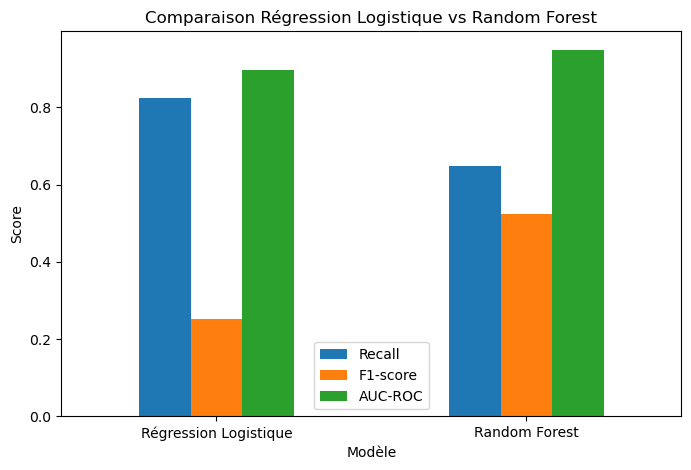

In [10]:
results_df.plot(
    x="Modèle",
    y=["Recall", "F1-score", "AUC-ROC"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparaison Régression Logistique vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

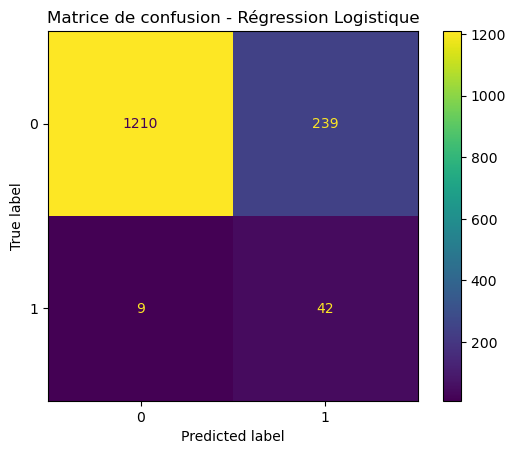

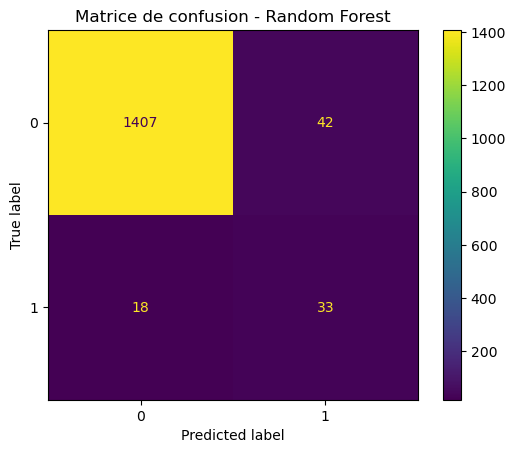

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Matrice de confusion - " + name)
    plt.show()

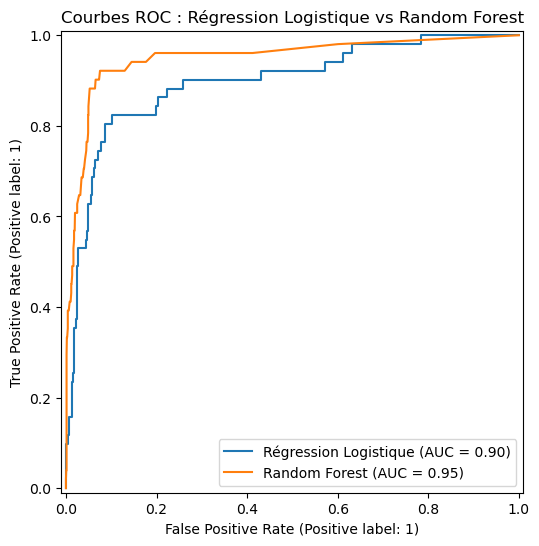

In [12]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("Courbes ROC : Régression Logistique vs Random Forest")
plt.show()

In [13]:
results_df.to_csv("metrics_ml_classique.csv", index=False)

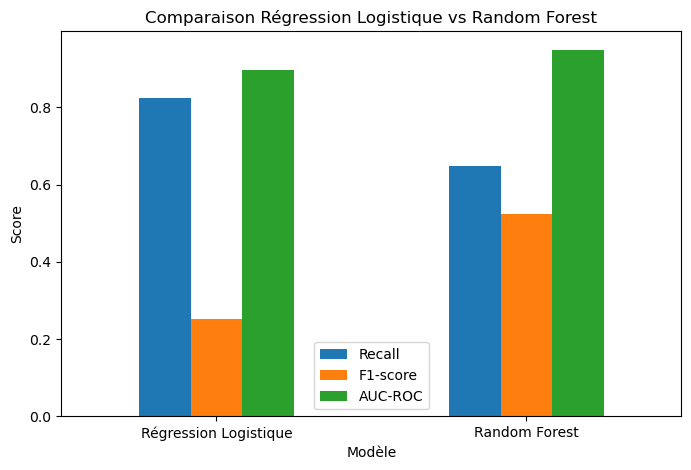

In [14]:
results_df.plot(
    x="Modèle",
    y=["Recall", "F1-score", "AUC-ROC"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparaison Régression Logistique vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig("comparaison_lr_rf.png", dpi=300, bbox_inches="tight")
plt.show()